In [46]:
%pip install kagglehub opencv-python numpy pandas tqdm brisque ipywidgets numba -q

import os
import cv2
import numpy as np
import pandas as pd
import kagglehub
from pathlib import Path
from tqdm import tqdm
import time
from brisque import BRISQUE
import warnings
import shutil
import matplotlib.pyplot as plt
from numba import njit
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [47]:
BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / "dataset_raw"

dataset_path = Path(
    kagglehub.dataset_download("tombackert/brain-tumor-mri-data")
)

# copia para dentro do projeto
shutil.copytree(dataset_path, DATASET_DIR, dirs_exist_ok=True)

print("Dataset copiado para:", DATASET_DIR)

INPUT_BASE = Path(dataset_path) / "brain-tumor-mri-dataset"
OUTPUT_BASE = "./dataset_exp1"
INTERMEDIATE_BASE = "./intermediarias_exp1"
TARGET_SIZE = (224, 224)
CLASSES = ['glioma', 'notumor', 'meningioma', 'pituitary']

# Principais
for cls in CLASSES:
    Path(os.path.join(OUTPUT_BASE, cls)).mkdir(parents=True, exist_ok=True)

# Intermediárias
for etapa in ['original', 'cropped', 'nlm', 'equalized', 'final']:
    Path(os.path.join(INTERMEDIATE_BASE, etapa)).mkdir(parents=True, exist_ok=True)

print(f"Pastas criadas:\n  - Saída: {OUTPUT_BASE}\n  - Intermediárias: {INTERMEDIATE_BASE}")

Dataset copiado para: c:\Users\marin\Desktop\a\dataset_raw
Pastas criadas:
  - Saída: ./dataset_exp1
  - Intermediárias: ./intermediarias_exp1


In [48]:
def central_crop(image):
    h, w = image.shape
    size = min(h, w)
    start_h = (h - size) // 2
    start_w = (w - size) // 2
    return image[start_h:start_h+size, start_w:start_w+size]

@njit
def non_local_means_core(
    padded,
    height,
    width,
    patch_radius,
    search_radius,
    kernel,
    h
):
    output = np.zeros((height, width), dtype=np.float32)
    pad = patch_radius + search_radius
    h2 = 2.0 * h * h
    for i in range(height):
        for j in range(width):

            i_c = i + pad
            j_c = j + pad

            weighted_sum = 0.0
            sum_weights = 0.0
            for si in range(-search_radius, search_radius + 1):
                for sj in range(-search_radius, search_radius + 1):

                    ni = i_c + si
                    nj = j_c + sj

                    dist = 0.0
                    for pi in range(-patch_radius, patch_radius + 1):
                        for pj in range(-patch_radius, patch_radius + 1):

                            center_pixel = padded[
                                i_c + pi,
                                j_c + pj
                            ]

                            neighbor_pixel = padded[
                                ni + pi,
                                nj + pj
                            ]

                            diff = center_pixel - neighbor_pixel

                            dist += (
                                kernel[
                                    pi + patch_radius,
                                    pj + patch_radius
                                ]
                                * diff
                                * diff
                            )

                    weight = np.exp(-dist / h2)
                    weighted_sum += (
                        weight * padded[ni, nj]
                    )
                    sum_weights += weight
            output[i, j] = weighted_sum / sum_weights
    return output

def non_local_means(
    img,
    h=0.03,
    patch_size=3,
    search_size=5
):
    img = img.astype(np.float32) / 255.0
    height, width = img.shape
    patch_radius = patch_size // 2
    search_radius = search_size // 2
    pad = patch_radius + search_radius
    padded = np.pad(
        img,
        pad,
        mode='reflect'
    )
    if patch_size == 3:
        kernel = np.array([
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1]
        ], dtype=np.float32)
    elif patch_size == 5:
        kernel = np.array([
            [1,  4,  7,  4, 1],
            [4, 16, 26, 16, 4],
            [7, 26, 41, 26, 7],
            [4, 16, 26, 16, 4],
            [1,  4,  7,  4, 1]
        ], dtype=np.float32)
    else:
        kernel = np.ones(
            (patch_size, patch_size),
            dtype=np.float32
        )

    kernel /= kernel.sum()
    output = non_local_means_core(
        padded,
        height,
        width,
        patch_radius,
        search_radius,
        kernel,
        np.float32(h)
    )
    output = np.clip(output, 0, 1)
    return (output * 255).astype(np.uint8)

@njit
def manual_histogram_equalization(img):
    h, w = img.shape
    hist = np.zeros(256, dtype=np.int64)

    for i in range(h):
        for j in range(w):
            hist[img[i, j]] += 1
    cdf = np.empty(256, dtype=np.int64)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]
    cdf_min = 0
    for i in range(256):
        if cdf[i] > 0:
            cdf_min = cdf[i]
            break
    total_pixels = h * w
    lut = np.zeros(256, dtype=np.uint8)
    if total_pixels > cdf_min:
        for i in range(256):
            value = (cdf[i] - cdf_min) * 255.0 / (total_pixels - cdf_min)

            if value < 0:
                value = 0
            elif value > 255:
                value = 255
            lut[i] = np.uint8(value)
    output = np.empty_like(img)
    for i in range(h):
        for j in range(w):
            output[i, j] = lut[img[i, j]]
    return output

In [ ]:
IMAGES_PER_CLASS = None
SAVE_INTERMEDIATE = True

print("\nExperimento 1\n")
brisque_obj = BRISQUE(url=False)
all_data = []
total_processed = 0
for cls in CLASSES:
    input_dir = os.path.join(INPUT_BASE, cls)
    output_dir = os.path.join(OUTPUT_BASE, cls)
    image_files = [f for f in os.listdir(input_dir)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if IMAGES_PER_CLASS:
        image_files = image_files[:IMAGES_PER_CLASS]

    print(f"\nClasse {cls}: {len(image_files)} imagens")

    for filename in tqdm(image_files, desc=f"  {cls}"):
        img_path = os.path.join(input_dir, filename)
        img_original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_original is None:
            continue

        img_cropped = central_crop(img_original)
        img_nlm = non_local_means(img_cropped, h=0.03, patch_size=3, search_size=5)
        img_equalized = manual_histogram_equalization(img_nlm)
        img_final = cv2.resize(img_equalized, TARGET_SIZE, interpolation=cv2.INTER_AREA)

        cv2.imwrite(os.path.join(output_dir, filename), img_final)

        if SAVE_INTERMEDIATE:
            orig_resized = cv2.resize(img_original, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            cropped_resized = cv2.resize(img_cropped, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            nlm_resized = cv2.resize(img_nlm, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            eq_resized = cv2.resize(img_equalized, TARGET_SIZE, interpolation=cv2.INTER_AREA)

            cv2.imwrite(os.path.join(INTERMEDIATE_BASE, 'original', filename), orig_resized)
            cv2.imwrite(os.path.join(INTERMEDIATE_BASE, 'cropped', filename), cropped_resized)
            cv2.imwrite(os.path.join(INTERMEDIATE_BASE, 'nlm', filename), nlm_resized)
            cv2.imwrite(os.path.join(INTERMEDIATE_BASE, 'equalized', filename), eq_resized)
            cv2.imwrite(os.path.join(INTERMEDIATE_BASE, 'final', filename), img_final)

        img_orig_resized = cv2.resize(img_original, TARGET_SIZE, interpolation=cv2.INTER_AREA)

        # MSE, PSNR e BRISQUE
        mse = np.mean((img_orig_resized.astype(np.float64) - img_final.astype(np.float64)) ** 2)

        psnr = 10 * np.log10((255.0 ** 2) / mse) if mse > 0 else float('inf')

        try:
            img_rgb = cv2.cvtColor(img_final, cv2.COLOR_GRAY2RGB)
            brisque_score = brisque_obj.score(img_rgb)
        except Exception as e:
            print(f"Erro BRISQUE em {filename}: {e}")
            brisque_score = None
        all_data.append({
            'classe': cls,
            'imagem': filename,
            'mse': round(mse, 4),
            'psnr': round(psnr, 4),
            'brisque': round(brisque_score, 4) if brisque_score is not None else None
        })
        total_processed += 1

print(f"\nFim {total_processed} imagens.")

df = pd.DataFrame(all_data)
csv_path = "metricas_experimento1.csv"
df.to_csv(csv_path, index=False)
print(f"CSV salvo em: {csv_path}")

INPUT_BASE: C:\Users\marin\.cache\kagglehub\datasets\tombackert\brain-tumor-mri-data\versions\1\brain-tumor-mri-dataset
['glioma', 'meningioma', 'notumor', 'pituitary']

Experimento 1


Classe glioma: 1621 imagens


  glioma: 100%|██████████| 1621/1621 [10:19<00:00,  2.62it/s]



Classe notumor: 2000 imagens


  notumor: 100%|██████████| 2000/2000 [07:44<00:00,  4.31it/s]



Classe meningioma: 1775 imagens


  meningioma: 100%|██████████| 1775/1775 [10:36<00:00,  2.79it/s]



Classe pituitary: 1757 imagens


  pituitary: 100%|██████████| 1757/1757 [11:12<00:00,  2.61it/s]


Fim 7153 imagens.
CSV salvo em: metricas_experimento1.csv


In [50]:
df = pd.read_csv("./metricas_experimento1.csv")

print("\n" + "="*50)
print("ESTATÍSTICAS GERAIS")
print("="*50)
print(df[['mse', 'psnr', 'brisque']].describe())

print("\n" + "="*50)
print("MÉDIAS POR CLASSE")
print("="*50)
print(df.groupby('classe')[['mse', 'psnr', 'brisque']].mean().round(4))

# Verificação BRISQUE
print("\n" + "="*50)
print("VERIFICAÇÃO DO BRISQUE")
print("="*50)
brisque_vals = df['brisque'].dropna()
if len(brisque_vals) > 0:
    media_brisque = brisque_vals.mean()
    print(f"Média BRISQUE: {media_brisque:.2f}")
    print(f"Valores típicos esperados para imagens processadas: entre 20 e 60 (quanto menor, melhor)")
    if media_brisque < 20:
        print("BRISQUE muito baixo → excelente qualidade perceptual (pode ser bom demais, verifique se não houve erro).")
    elif media_brisque < 40:
        print("BRISQUE na faixa boa → qualidade perceptual adequada.")
    elif media_brisque < 60:
        print("BRISQUE médio → qualidade perceptual razoável, pode ser melhorada.")
    else:
        print("BRISQUE alto (>60) → qualidade perceptual baixa. Verifique os parâmetros do NLM/equalização.")
else:
    print("Nenhum valor de BRISQUE calculado.")

df.groupby('classe')[['mse', 'psnr', 'brisque']].mean().round(4).to_csv("/content/medias_por_classe.csv")
print("\nResumo por classe salvo em: /content/medias_por_classe.csv")


ESTATÍSTICAS GERAIS
                mse         psnr      brisque
count   7153.000000  7153.000000  7153.000000
mean    6913.094883    10.119908    33.582506
std     2266.045495     2.358558    14.061412
min       46.191400     3.350700     1.312000
25%     5761.033900     9.047600    22.168000
50%     6920.990200     9.729100    33.466700
75%     8096.960800    10.525800    43.393600
max    30061.526500    31.485200   119.547300

MÉDIAS POR CLASSE
                  mse     psnr  brisque
classe                                 
glioma      7737.1763   9.3321  37.7871
meningioma  7112.4540   9.8225  36.5662
notumor     6346.6925  11.0950  38.2511
pituitary   6596.1378  10.0372  21.3748

VERIFICAÇÃO DO BRISQUE
Média BRISQUE: 33.58
Valores típicos esperados para imagens processadas: entre 20 e 60 (quanto menor, melhor)
BRISQUE na faixa boa → qualidade perceptual adequada.

Resumo por classe salvo em: /content/medias_por_classe.csv


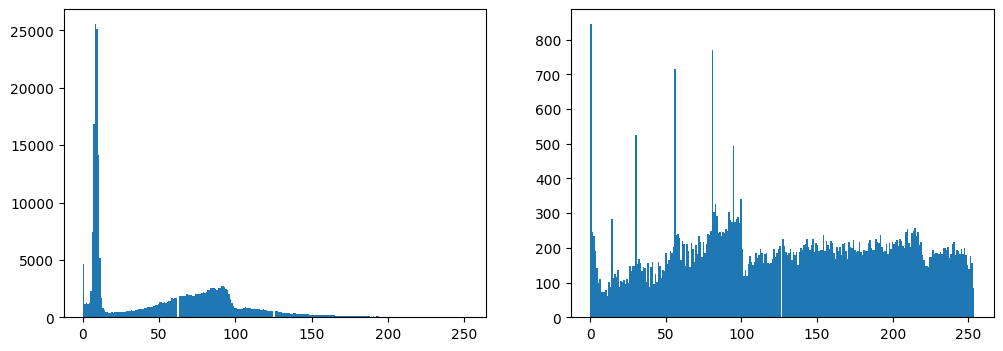

In [51]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(img_nlm.ravel(), bins=256)

plt.subplot(1,2,2)
plt.hist(img_final.ravel(), bins=256)

plt.show()

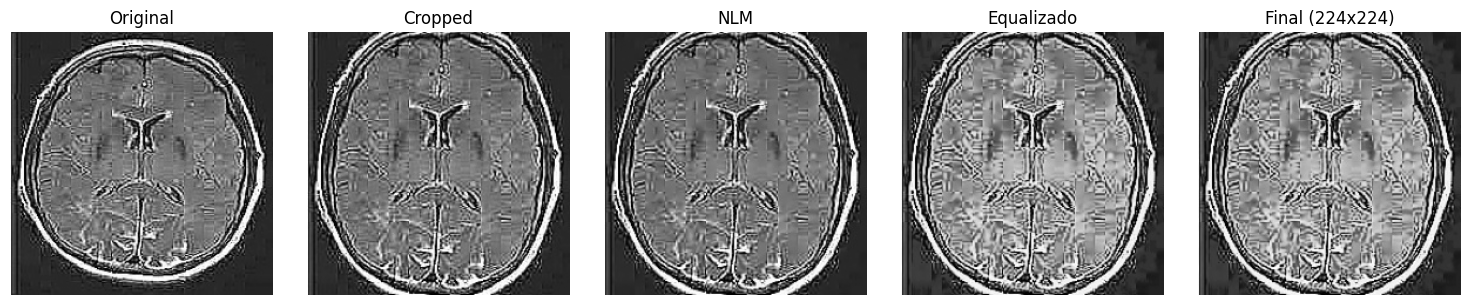

In [52]:
import matplotlib.pyplot as plt

exemplo_arquivo = "no-0001.jpg"

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
etapas = ['original', 'cropped', 'nlm', 'equalized', 'final']
titulos = ['Original', 'Cropped', 'NLM', 'Equalizado', 'Final (224x224)']

for ax, etapa, titulo in zip(axes, etapas, titulos):
    img = cv2.imread(os.path.join(INTERMEDIATE_BASE, etapa, exemplo_arquivo), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(titulo)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
shutil.make_archive("dataset_exp1", "zip", "./dataset_exp1")
shutil.make_archive("intermediarias_exp1", "zip", "./intermediarias_exp1")